# XGBoost

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold

from heart_failure.features import get_preprocessor
from heart_failure.dataset import split_data
from heart_failure.modeling.models import build_xgboost_pipeline
from heart_failure.modeling.train import optuna_search, xgboost_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, F_BETA_THRESHOLD, MIN_RECALL
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE, TE_CV, CAT_FEATURES
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-24 16:36:09.561 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "xgboost"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)
fe_pipeline = get_preprocessor(cv)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
)

In [6]:
print_best_params(study)

Best parameters: {'model__n_estimators': 565, 'model__learning_rate': 0.020358998219956497, 'model__gamma': 1.1115271937203521, 'model__max_depth': 2, 'model__reg_lambda': 0.48605994383469053, 'model__reg_alpha': 0.03359897462764235, 'model__subsample': 0.991847447602227}
Best score: 0.94102


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
41,"{'model__n_estimators': 565, 'model__learning_...",0.027993,0.941023,0.936209,0.891567,0.944234,0.974772,0.958335,1
46,"{'model__n_estimators': 574, 'model__learning_...",0.028750,0.940661,0.935868,0.889339,0.945162,0.974329,0.958607,2
40,"{'model__n_estimators': 552, 'model__learning_...",0.028918,0.940492,0.936291,0.888746,0.944740,0.974451,0.958231,3
36,"{'model__n_estimators': 782, 'model__learning_...",0.029466,0.940486,0.934346,0.888272,0.945157,0.974894,0.959760,4
29,"{'model__n_estimators': 609, 'model__learning_...",0.029364,0.939961,0.934528,0.887408,0.945374,0.973617,0.958880,5


#### Feature importance

In [8]:
tree = model.named_steps["model"]
pd.Series(tree.feature_importances_, index=fe_pipeline.transform(X).columns).sort_values(ascending=False)

target_encoder__ST_Slope          0.385233
binary_encoder__ExerciseAngina    0.207673
target_encoder__ChestPainType     0.083145
binary_encoder__FastingBS         0.062301
binary_encoder__Sex               0.059366
binarizer__MaxHR                  0.044850
remainder__Oldpeak                0.044069
binarizer__Age                    0.038587
binarizer__Cholesterol            0.029788
target_encoder__RestingECG        0.024527
remainder__RestingBP              0.020461
dtype: float32

### Threshold searching

In [9]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float32(0.23633938)

## Metrics

In [10]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.886486
recall       0.921348
fpr          0.145329
pr_auc       0.962301
dtype: float64

In [11]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.774194
recall       0.979592
fpr          0.358974
pr_auc       0.943556
dtype: float64

The model is better than all previous ones, but the FPR is still too high. I'd like to see it reduced to at least 0.25.

### Confusion Matrix

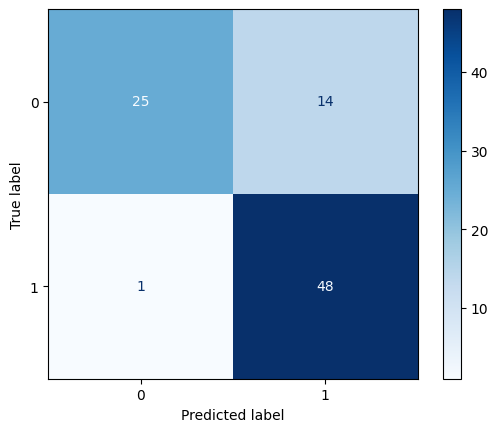

In [12]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

### PR-curve

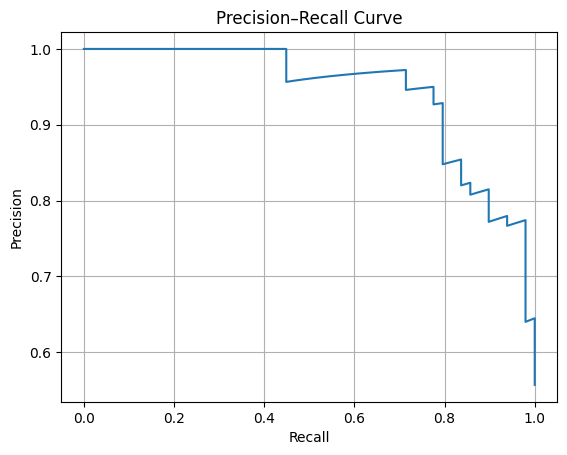

In [13]:
plot_pr_curve(y_val, y_val_proba)

### Test metrics

In [14]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.770992
recall       0.990196
fpr          0.365854
pr_auc       0.910241
dtype: float64

Next, I want to consider the following questions:
- Why is the score always worse on split_1 than on the other splits?
- How can the models be improved? What features should be added?
- Comparison of models and their predictions. Do they have the same FN?
- Which model is currently the best?

In [ ]:
cv_results = optuna_cv_results_to_df(study)

with mlflow.start_run(run_name=MODEL_NAME) as run:
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(best_cv_result, artifact_file="best_cv_result.json")
    for i in range(CV_SPLITS):
        mlflow.log_metric(f"cv_split_{i}_score", best_cv_result[f"split_test_{i}"])

    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", "all")
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")

## Version with raw features

In [4]:
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].astype("category")

In [5]:
y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

In [ ]:
fe_pipeline = FunctionTransformer(lambda x: x, validate=False)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_xgboost_pipeline,
    param_space=xgboost_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    cat_features=True
)

In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
48,"{'model__n_estimators': 633, 'model__learning_...",0.028046,0.935111,0.927512,0.885290,0.942027,0.966273,0.954455,1
43,"{'model__n_estimators': 600, 'model__learning_...",0.027265,0.934697,0.927281,0.886481,0.940856,0.965568,0.953301,2
17,"{'model__n_estimators': 602, 'model__learning_...",0.032115,0.933888,0.930515,0.874849,0.941503,0.968371,0.954203,3
30,"{'model__n_estimators': 578, 'model__learning_...",0.025055,0.933064,0.927935,0.890603,0.931860,0.965127,0.949797,4
13,"{'model__n_estimators': 712, 'model__learning_...",0.024112,0.932908,0.932246,0.888686,0.938083,0.961002,0.944524,5


In [8]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float32(0.32346404)

### Metrics

In [9]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.876344
recall       0.915730
fpr          0.159170
pr_auc       0.952530
dtype: float64

In [10]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.770492
recall       0.959184
fpr          0.358974
pr_auc       0.932943
dtype: float64

In [11]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.782258
recall       0.950980
fpr          0.329268
pr_auc       0.921209
dtype: float64

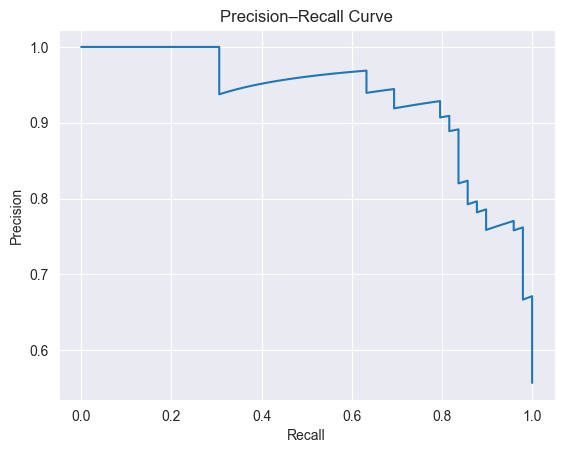

In [12]:
plot_pr_curve(y_val, y_val_proba)

Metrics are slightly worse on validation set and folds. Accordingly, it is better to use XGBoost with transformed features.